## USING THE FULL POWER OF THE CPU

In [36]:
using LinearAlgebra
println("Active Julia Threads: $(Threads.nthreads()) / $(Sys.CPU_THREADS)") 

# Maximize multi-threading for matrix operations
BLAS.set_num_threads(Sys.CPU_THREADS)
# Print confirmation to verify full thread usage
println("Active Julia Threads: $(Threads.nthreads()) / $(Sys.CPU_THREADS)")
println("BLAS Threads: $(BLAS.get_num_threads())")

Active Julia Threads: 28 / 28
Active Julia Threads: 28 / 28
BLAS Threads: 28


## IMPORTING ALL THE IMPORTANT LIBRARY

In [37]:
using DataFrames, DifferentialEquations, OrdinaryDiffEq, Plots, CSV, Random, Lux, Optimization
using OptimizationOptimisers            # <--- ADD THIS LINE (provides Adam)
using OptimizationOptimJL: BFGS  # <--- Added BFGS for Phase 3
using Zygote, ComponentArrays, SciMLSensitivity, JLD2, StaticArrays, ForwardDiff
using Plots
using JLD2

## LOADING THE DATA

In [38]:
# loading the data
data_loaded = CSV.read("C:/Ude_HH_model/ude_models/synthetic_data.csv", DataFrame)

names(data_loaded)

5-element Vector{String}:
 "Time"
 "V"
 "m"
 "h"
 "n"

# DEFINIG ALL THE CONSTANTS

In [39]:
# all constants
true_n = Float32.(data_loaded[!, "n"])
true_V = Float32.(data_loaded[!, "V"])

true_m = Float32.(data_loaded[!, "m"])
true_h = Float32.(data_loaded[!, "h"])
t_steps = Float32.(data_loaded[!, "Time"])
# all constants
const g_na = 120.0f0
const g_k = 36.0f0
const g_l = 0.3f0
const c_m = 1.0f0
const I_ext = 10.0f0
const E_na = 50.0f0
const E_k = -77.0f0
const E_l = -54.4f0
const u_0 = Float32[-65.0f0, 0.05f0, 0.6f0, 0.317f0]


4-element Vector{Float32}:
 -65.0
   0.05
   0.6
   0.317

## DEFINIGING ALL THE RATE CONSTANTS

In [40]:

# --- Potassium Gating (n) ---
alpha_n(V) = abs(V + 55.0f0) < 1.0f-6 ? 0.1f0 : 0.01f0 * (V + 55.0f0) / (1.0f0 - exp(-(V + 55.0f0) / 10.0f0))
beta_n(V) = 0.125f0 * exp(-(V + 65.0f0) / 80.0f0)

beta_n (generic function with 1 method)

In [41]:
# --- Sodium Activation (m) ---
alpha_m(V) = abs(V + 40.0f0) < 1.0f-6 ? 1.0f0 : 0.1f0 * (V + 40.0f0) / (1.0f0 - exp(-(V + 40.0f0) / 10.0f0))
beta_m(V) = 4.0f0 * exp(-(V + 65.0f0) / 18.0f0)

beta_m (generic function with 1 method)

In [42]:
# --- Sodium Inactivation (h) ---
alpha_h(V) = 0.07f0 * exp(-(V + 65.0f0) / 20.0f0)
beta_h(V) = 1.0f0 / (1.0f0 + exp(-(V + 35.0f0) / 10.0f0))

beta_h (generic function with 1 method)

## DEFINGING THE RANDOM SEED 

In [43]:
rng = Random.seed!(42)
Random.seed!(42)

TaskLocalRNG()

# ADDING NOIE TO THE DATA

In [44]:
noise_std_V = 1.5f0     # 1.5 mV noise (or 0.05f0 * std(true_V))
noise_std_n = 0.005f0    # 2% gating probability noise
noise_std_m = 0.015f0
noise_std_h = 0.015f0


noisy_V = true_V .+ noise_std_V .* randn(Float32, size(true_V))
noisy_n = (true_n .+ noise_std_n .* randn(Float32, size(true_n)))
noisy_h = (true_h .+ noise_std_n .* randn(Float32, size(true_n)))
noisy_m = (true_m .+ noise_std_m .* randn(Float32, size(true_m)))


noise_n = clamp.(noisy_n, 0.0f0, 1.0f0)
noise_m = clamp.(noisy_m, 0.0f0, 1.0f0)
noise_h = clamp.(noisy_h, 0.0f0, 1.0f0)

# Create a DataFrame containing the noisy data
noisy_df = DataFrame(
    Time=t_steps,
    V=noisy_V,
    n=noise_n,
    m=noise_m,
    h=noise_h
)


Row,Time,V,n,m,h
,Float32,Float32,Float32,Float32,Float32
1,0.0,-63.8175,0.304739,0.0410641,0.606856
2,0.01,-66.2215,0.317815,0.0433308,0.603907
3,0.02,-66.1148,0.316591,0.0695857,0.599555
4,0.03,-65.8069,0.312068,0.0540586,0.602316
5,0.04,-65.6637,0.316107,0.0668265,0.595131
6,0.05,-64.6233,0.316842,0.0568176,0.595027
7,0.06,-65.7883,0.316379,0.0414605,0.604426
8,0.07,-63.3764,0.327422,0.0511976,0.598935
9,0.08,-62.0713,0.314563,0.0513079,0.602126


## SAVING THE NOISY DATA

In [45]:
# Save to CSV
CSV.write("C:/Ude_HH_model/ude_models/noisy_data.csv", noisy_df)
println("Noisy data successfully saved to C:/Ude_HH_model/ude_models/noisy_data.csv")


Noisy data successfully saved to C:/Ude_HH_model/ude_models/noisy_data.csv


## PLOTING THE NOISY DATA

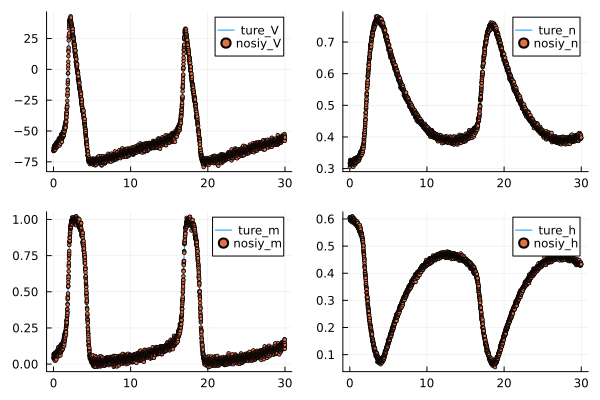

In [46]:
# ploing the noise vs ture data 

v_plot = plot(t_steps, true_V, label=" ture_V")
P1 = plot(v_plot, t_steps, noisy_V, seriestype=:scatter, markersize=2, label="nosiy_V")

n_plot = plot(t_steps, true_n, label=" ture_n")
P2 = plot(n_plot, t_steps, noisy_n, seriestype=:scatter, markersize=2, label="nosiy_n")

m_plot = plot(t_steps, true_m, label=" ture_m")
P3 = plot(m_plot, t_steps, noisy_m, seriestype=:scatter, markersize=2, label="nosiy_m")

h_plot = plot(t_steps, true_h, label=" ture_h")
P4 = plot(h_plot, t_steps, noisy_h, seriestype=:scatter, markersize=2, label="nosiy_h")
plot(P1,P2,P3,P4)


## DEFINIG THE NETWORK STRUCTURE

In [47]:
nn = Chain(Dense(1 => 32),
    Dense(32 => 32, tanh),
    Dense(32 => 1, sigmoid))
ps, st = Lux.setup(rng, nn)

((layer_1 = (weight = Float32[-0.66900235; -0.6756094; … ; -0.9179381; -1.3581051;;], bias = Float32[-0.19202888, 0.2995262, 0.423249, -0.61139536, -0.7873994, 0.8984288, -0.8261312, -0.2916293, -0.4488083, -0.68159544  …  -0.45452905, -0.51798725, -0.3470286, 0.77204514, 0.83566344, -0.85105276, 0.5824635, -0.28846407, -0.67946243, 0.15259266]), layer_2 = (weight = Float32[0.39352328 -0.380182 … 0.011116635 0.1706528; -0.20279296 -0.3710559 … 0.17124806 0.22535017; … ; -0.45324412 -0.0922939 … 0.13001417 -0.23973814; -0.24350831 0.0119914245 … 0.4011691 0.35535848], bias = Float32[-0.16448541, -0.059646662, -0.04362397, 0.02546108, 0.16881596, 0.010323871, -0.12484992, 0.09493681, -0.10200945, -0.16022514  …  -0.13451664, -0.10194602, -0.10459984, 0.008591066, -0.14960101, 0.069827594, 0.09575199, 0.106102265, -0.11859071, -0.104080655]), layer_3 = (weight = Float32[0.1881201 0.19667043 … 0.305598 -0.26658222], bias = Float32[0.06446814])), (layer_1 = NamedTuple(), layer_2 = NamedTupl

## DEFINING THE UDE FOR HH 4D MODEL TO TRANING THE ABOVE NETWORK

In [48]:
function ude_hh(u, ps, t)
    V, m, h, n = u
    pred_n, _ = nn(SA[n], ps, st)
    n_val = clamp(pred_n[1], 0.0f0, 1.0f0)


    dV = (I_ext - g_na * m^3 * h * (V - E_na) - g_k * n_val * (V - E_k) - g_l * (V - E_l)) / c_m
    dm = alpha_m(V) * (1.0f0 - m) - beta_m(V) * m
    dh = alpha_h(V) * (1.0f0 - h) - beta_h(V) * h
    dn = alpha_n(V) * (1.0f0 - n) - beta_n(V) * n

    return @SVector [dV, dm, dh, dn]
end


ude_hh (generic function with 1 method)

## SETTING THE INITIAL VALUES OF UDE EQUATION 

In [49]:
# Define with StaticArray initial conditions:
const u_0 = @SVector [-65.0f0, 0.05f0, 0.6f0, 0.317f0]
tspan = (0.0f0, 30.0f0)
p = [g_na, g_k, g_l, c_m, I_ext, E_na, E_k, E_l, ps, st]
prob = ODEProblem(ude_hh, u_0, tspan, p)


ODEProblem with uType SVector{4, Float32} and tType Float32. In-place: false
Non-trivial mass matrix: false
timespan: (0.0f0, 30.0f0)
u0: 4-element SVector{4, Float32} with indices SOneTo(4):
 -65.0
   0.05
   0.6
   0.317

## DEFINING THE LOSS FUNCTION


In [50]:
function loss_function(ps, p)
    prob = ODEProblem(ude_hh, u_0, tspan, ps)
    sol = solve(
        prob,
        Rosenbrock23(),
        reltol=1e-4,
        abstol=1e-4,
        saveat=t_steps,
        sensealg=ForwardDiffSensitivity(),
        force_dtmin=true
    )

    pred_V = sol[1, :]
    return sum(abs2, pred_V - true_V) / length(true_V)
end

loss_function (generic function with 1 method)

Optimization

## CREATING AN CALLBACK FUNTION TO STORE AND SHOW LOGS

In [52]:
const loss_history = []
const iter_history = []
function callback(state, l)

    push!(loss_history, Float32(l))
    push!(iter_history, state.iter)
    if state.iter % 10 == 0
        println("current iteration = $(state.iter)  | current_loss = $(l)")
        if state.iter % 100 == 0
            jldsave("C:/Ude_HH_model/ude_models/leaning_parameter.jld2"; p=state.u)
        end
    end
    return false
end

callback (generic function with 1 method)

## DEFINIG THE OPTIMIZATION  FUNCTION FOR OUR UDE MODEL

In [35]:
opt = OptimizationFunction(loss_function, AutoForwardDiff())

# Optimization

net = ComponentArray(ps)
opt_prob = OptimizationProblem(opt, net)


OptimizationProblem. In-place: true
u0: ComponentVector{Float32}(layer_1 = (weight = Float32[-0.66900235; -0.6756094; … ; -0.9179381; -1.3581051;;], bias = Float32[-0.19202888, 0.2995262, 0.423249, -0.61139536, -0.7873994, 0.8984288, -0.8261312, -0.2916293, -0.4488083, -0.68159544  …  -0.45452905, -0.51798725, -0.3470286, 0.77204514, 0.83566344, -0.85105276, 0.5824635, -0.28846407, -0.67946243, 0.15259266]), layer_2 = (weight = Float32[0.39352328 -0.380182 … 0.011116635 0.1706528; -0.20279296 -0.3710559 … 0.17124806 0.22535017; … ; -0.45324412 -0.0922939 … 0.13001417 -0.23973814; -0.24350831 0.0119914245 … 0.4011691 0.35535848], bias = Float32[-0.16448541, -0.059646662, -0.04362397, 0.02546108, 0.16881596, 0.010323871, -0.12484992, 0.09493681, -0.10200945, -0.16022514  …  -0.13451664, -0.10194602, -0.10459984, 0.008591066, -0.14960101, 0.069827594, 0.09575199, 0.106102265, -0.11859071, -0.104080655]), layer_3 = (weight = Float32[0.1881201 0.19667043 … 0.305598 -0.26658222], bias = Floa

## PREPARING FOR TRAINING THE UDE MODEL 

### PHASE 1 : ADAM( O.025)  ---> 1000

In [ ]:
println("Lets start the training ====================================== ")
# -------------------------------------------
# 1st optimization loop: Adam(0.05) -- 1500 iterations

println("--- Phase 1: Adam(0.005) [1500 maxiters] ---")
res1 = solve(opt_prob, Adam(0.0025), callback=callback, maxiters=1000)


Lets start the training ====================================== 
--- Phase 1: Adam(0.005) [1500 maxiters] ---
current iteration = 10  | current_loss = 991.9429
current iteration = 20  | current_loss = 1424.2913
current iteration = 30  | current_loss = 2752.081
current iteration = 40  | current_loss = 2812.5981
current iteration = 50  | current_loss = 2816.5305
current iteration = 60  | current_loss = 2763.5989
current iteration = 70  | current_loss = 2677.3943
current iteration = 80  | current_loss = 2570.8118
current iteration = 90  | current_loss = 2451.898
current iteration = 100  | current_loss = 2327.788
current iteration = 110  | current_loss = 2204.7002
current iteration = 120  | current_loss = 2086.2705
current iteration = 130  | current_loss = 1973.0284
current iteration = 140  | current_loss = 1862.9512
current iteration = 150  | current_loss = 1749.7867
current iteration = 160  | current_loss = 1631.9393
current iteration = 170  | current_loss = 1622.3904
current iteration = 

### PHASE 2 : ADAM( O.05)  ---> 200

In [ ]:
# 2nd optimization loop: Adam(0.01) -- 1000 iterations
println("--- Phase 2: Adam(0.0005) [2000 maxiters] ---")
opt_prob2 = remake(opt_prob, u0=res1.u)
res2 = solve(opt_prob2, Adam(0.005), callback=callback, maxiters=200)

### PHASE 3 : BFGS  ---> 200

In [ ]:

# 3rd optimization loop: LBFGS -- 500 iterations
println("--- Phase 3: BFGS [200 maxiters] ---")
opt_prob3 = remake(opt_prob, u0=res2.u)
res3 = solve(opt_prob3, BFGS(), callback=callback, maxiters=200)

--- Phase 2: Adam(0.0005) [2000 maxiters] ---


LoadError: UndefVarError: `res1` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [ ]:
# Save final parameters
jldsave("C:/Ude_HH_model/ude_models/leaning_parameter2.jld2"; p=res3.u)
println("Training completed and parameters saved to C:/Ude_HH_model/ude_models/leaning_parameter2.jld2")

--------------------------------------------